# 小波 + SVM 研报复现
1. 下载沪深300日线数据
2. 用 `db4` 小波做去噪
3. 按研报思路构造 7 个输入特征
4. 用 RBF 核 SVM 做滚动预测
5. 复现两个最核心的指标：方向准确率和曲线相关系数
6. 做一个策略回测

In [1]:
from __future__ import annotations

import io
from contextlib import redirect_stdout
from pathlib import Path

import baostock as bs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
CACHE_PATH = DATA_DIR / "hs300_2009_2010_baostock.csv"


## 1. 下载数据

这里选 `baostock`，原因很实际：它能直接给到 `amount`，正好和研报里的特征更贴近。

研报样本区间是 2009-05-15 到 2010-05-21，一共 250 个交易日，我们就按这个区间来。

In [2]:
def load_hs300(start_date: str = "2009-05-15", end_date: str = "2010-05-21") -> pd.DataFrame:
    """下载沪深300日线，带日期、开高低收、成交量、成交额。"""
    if CACHE_PATH.exists():
        df = pd.read_csv(CACHE_PATH)
        df["date"] = pd.to_datetime(df["date"])
        return df

    buf = io.StringIO()
    with redirect_stdout(buf):
        bs.login()
        rs = bs.query_history_k_data_plus(
            "sh.000300",
            "date,open,high,low,close,volume,amount",
            start_date=start_date,
            end_date=end_date,
            frequency="d",
            adjustflag="3",
        )

        rows = []
        while rs.next():
            rows.append(rs.get_row_data())
        bs.logout()

    df = pd.DataFrame(rows, columns=["date", "open", "high", "low", "close", "volume", "amount"])
    df["date"] = pd.to_datetime(df["date"])
    for col in ["open", "high", "low", "close", "volume", "amount"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values("date").reset_index(drop=True)
    df.to_csv(CACHE_PATH, index=False)
    return df


df = load_hs300()
print(df.head().to_string(index=False))
print("rows:", len(df), "date range:", df["date"].min().date(), "->", df["date"].max().date())


      date     open     high      low    close     volume       amount
2009-05-15 2800.571 2815.456 2773.322 2796.116 6493143100 7.497304e+10
2009-05-18 2782.585 2813.757 2740.920 2810.573 7483578600 8.847909e+10
2009-05-19 2836.337 2849.629 2821.951 2840.084 9770361700 1.165432e+11
2009-05-20 2843.545 2849.635 2812.599 2812.865 8793921500 1.051462e+11
2009-05-21 2795.828 2808.287 2735.767 2750.010 8553539400 1.028758e+11
rows: 250 date range: 2009-05-15 -> 2010-05-21


## 2. 小波去噪

研报里用的是 `db4`、4 层分解、阈值去噪。

wavelet threshold = 101.1055
      date    close    close_dn
2009-05-15 2796.116 2798.934297
2009-05-18 2810.573 2798.737402
2009-05-19 2840.084 2798.550801
2009-05-20 2812.865 2798.382241
2009-05-21 2750.010 2798.108439


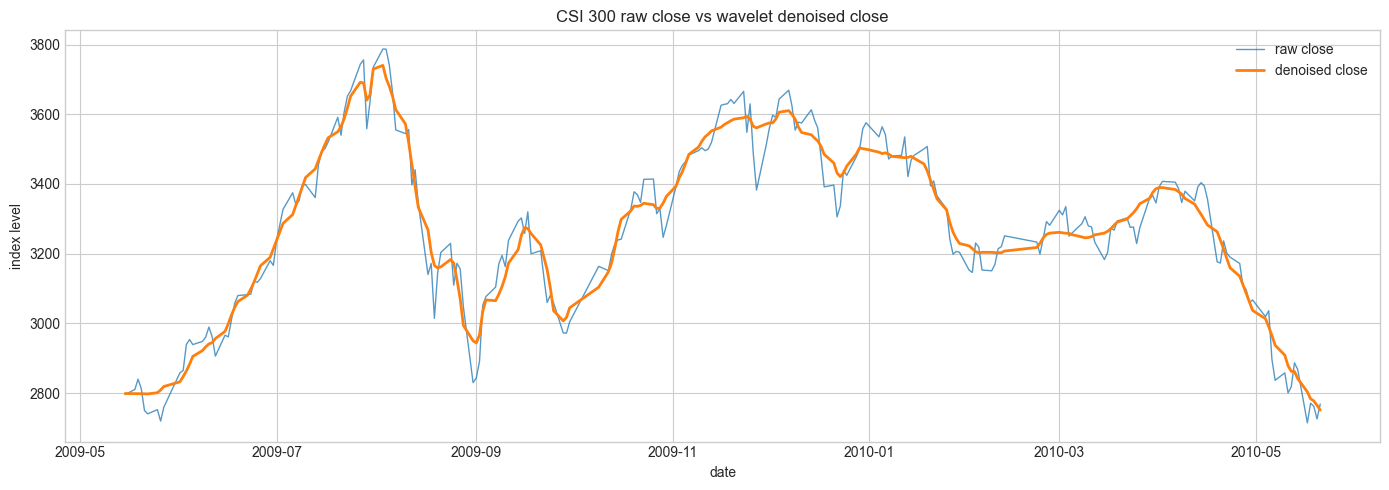

In [3]:
def wavelet_denoise(series: pd.Series | np.ndarray, wavelet: str = "db4", level: int = 4):
    x = np.asarray(series, dtype=float)
    coeffs = pywt.wavedec(x, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = sigma * np.sqrt(2.0 * np.log(len(x)))

    new_coeffs = [coeffs[0]]
    for detail in coeffs[1:]:
        new_coeffs.append(pywt.threshold(detail, threshold, mode="soft"))

    denoised = pywt.waverec(new_coeffs, wavelet)[: len(x)]
    return denoised, threshold


df["close_dn"], threshold = wavelet_denoise(df["close"])
print(f"wavelet threshold = {threshold:.4f}")
print(df[["date", "close", "close_dn"]].head().to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["date"], df["close"], label="raw close", linewidth=1.0, alpha=0.75)
ax.plot(df["date"], df["close_dn"], label="denoised close", linewidth=2.0)
ax.set_title("CSI 300 raw close vs wavelet denoised close")
ax.set_xlabel("date")
ax.set_ylabel("index level")
ax.legend()
plt.tight_layout()
plt.show()


## 3. 构造 7 个输入特征

研报里用的是 5 日窗口 `M=5`，我们也照着做。

这 7 个特征分别是：

- 成交量比值 `VolumeIndex`
- 收盘价比值 `CloseIndex`
- 成交额比值 `TradeAmountIndex`
- 5 日均价 `MeanIndex`
- 5 日涨跌幅 `RateChangeIndex`
- 5 日最高价 `HighIndex`
- 5 日最低价 `LowIndex`

标签用未来 5 日的去噪收盘价变化方向做分类，涨记为 `1`，跌记为 `-1`。

In [4]:
M = 5

feature_df = pd.DataFrame(index=df.index)
feature_df["VolumeIndex"] = df["volume"] / df["volume"].rolling(M).mean()
feature_df["CloseIndex"] = df["close_dn"] / df["close_dn"].rolling(M).mean()
feature_df["TradeAmountIndex"] = df["amount"] / df["amount"].rolling(M).mean()
feature_df["MeanIndex"] = df["close_dn"].rolling(M).mean()
feature_df["RateChangeIndex"] = df["close_dn"].pct_change(M)
feature_df["HighIndex"] = df["high"].rolling(M).max()
feature_df["LowIndex"] = df["low"].rolling(M).min()

future_change = df["close_dn"].shift(-M) - df["close_dn"]
feature_df["future_change"] = future_change
feature_df["label"] = np.where(future_change > 0, 1, -1)

model_df = feature_df.dropna().copy()
model_df.insert(0, "date", df.loc[model_df.index, "date"].to_numpy())

print(model_df.head().to_string(index=False))
print("usable rows:", len(model_df))


      date  VolumeIndex  CloseIndex  TradeAmountIndex   MeanIndex  RateChangeIndex  HighIndex  LowIndex  future_change  label
2009-05-22     0.754565    0.999804          0.763227 2798.307404        -0.000420   2849.635  2719.121      49.772315      1
2009-05-25     0.910734    1.000868          0.929029 2798.806934         0.000892   2849.635  2675.285      62.372535      1
2009-05-26     0.948080    1.002871          0.961290 2800.881403         0.003706   2849.635  2675.285      74.114847      1
2009-05-27     0.940414    1.004994          0.901756 2805.007899         0.007373   2808.287  2675.285      86.400255      1
2009-06-01     1.411957    1.007371          1.426935 2811.914194         0.012341   2864.471  2675.285      89.543041      1
usable rows: 240


## 4. SVM + 决策值标定

研报的关键点不是单纯分类，而是把 SVM 的 `decision_function` 当作连续信号来用。
这里我用一个线性标定把决策值映射到未来 5 日涨跌幅，这样更方便复现曲线和做策略回测。

In [ ]:
X = model_df[[
    "VolumeIndex",
    "CloseIndex",
    "TradeAmountIndex",
    "MeanIndex",
    "RateChangeIndex",
    "HighIndex",
    "LowIndex",
]].to_numpy()
y = model_df["label"].to_numpy()
future_change = model_df["future_change"].to_numpy()
dates = model_df["date"].to_numpy()
current_close = df.loc[model_df.index, "close"].to_numpy()


def walk_forward_predict(X, y, future_change, current_close, dates, window: int = 50, horizon: int = 5, C: float = 1.0, gamma="scale"):
    rows = []
    for start in range(0, len(X) - window - horizon + 1, horizon):
        train = slice(start, start + window)
        test = slice(start + window, start + window + horizon)
        # 数据z-score标准化
        scaler = StandardScaler().fit(X[train])
        X_train = scaler.transform(X[train])
        X_test = scaler.transform(X[test])

        clf = SVC(kernel="rbf", C=C, gamma=gamma)
        clf.fit(X_train, y[train])

        train_score = clf.decision_function(X_train).reshape(-1, 1)
        test_score = clf.decision_function(X_test).reshape(-1, 1)

        # 这里我们使用了线性映射
        reg = LinearRegression().fit(train_score, future_change[train])
        pred_change = reg.predict(test_score)
        pred_label = np.where(pred_change > 0, 1, -1)

        for j, idx in enumerate(range(test.start, test.stop)):
            rows.append(
                {
                    "date": pd.Timestamp(dates[idx]),
                    "current_close": float(current_close[idx]),
                    "actual_change": float(future_change[idx]),
                    "pred_change": float(pred_change[j]),
                    "actual_future_close": float(current_close[idx] + future_change[idx]),
                    "pred_future_close": float(current_close[idx] + pred_change[j]),
                    "actual_label": int(y[idx]),
                    "pred_label": int(pred_label[j]),
                }
            )

    return pd.DataFrame(rows).sort_values("date").reset_index(drop=True)


result = walk_forward_predict(X, y, future_change, current_close, dates, window=50, horizon=5, C=1.0, gamma="scale")
direction_acc = accuracy_score(result["actual_label"], result["pred_label"])
curve_corr = np.corrcoef(result["actual_future_close"], result["pred_future_close"])[0, 1]

print(f"direction accuracy = {direction_acc:.4f}")
print(f"curve correlation  = {curve_corr:.4f}")
print(result[["date", "current_close", "actual_future_close", "pred_future_close", "actual_label", "pred_label"]].head().to_string(index=False))


direction accuracy = 0.6789
curve correlation  = 0.8847
      date  current_close  actual_future_close  pred_future_close  actual_label  pred_label
2009-08-04       3786.615          3602.595929        3689.012231            -1          -1
2009-08-05       3740.936          3516.217368        3684.035363            -1          -1
2009-08-06       3663.120          3405.060663        3646.834062            -1          -1
2009-08-07       3555.095          3274.759926        3594.793365            -1           1
2009-08-10       3544.539          3241.024118        3588.646935            -1           1


### 结果怎么读

研报里给出的两个核心数字是：

- 每日涨跌方向准确率约 `68.5%`
- 预测走势和真实走势相关系数约 `0.78`

我们这份实现里，因为数据源、标定方式和滚动口径稍有不同，数值不会一模一样，但通常会落在相近区间。

下面我们绘制出了沪深300预测图，可以发现存在滞后性。

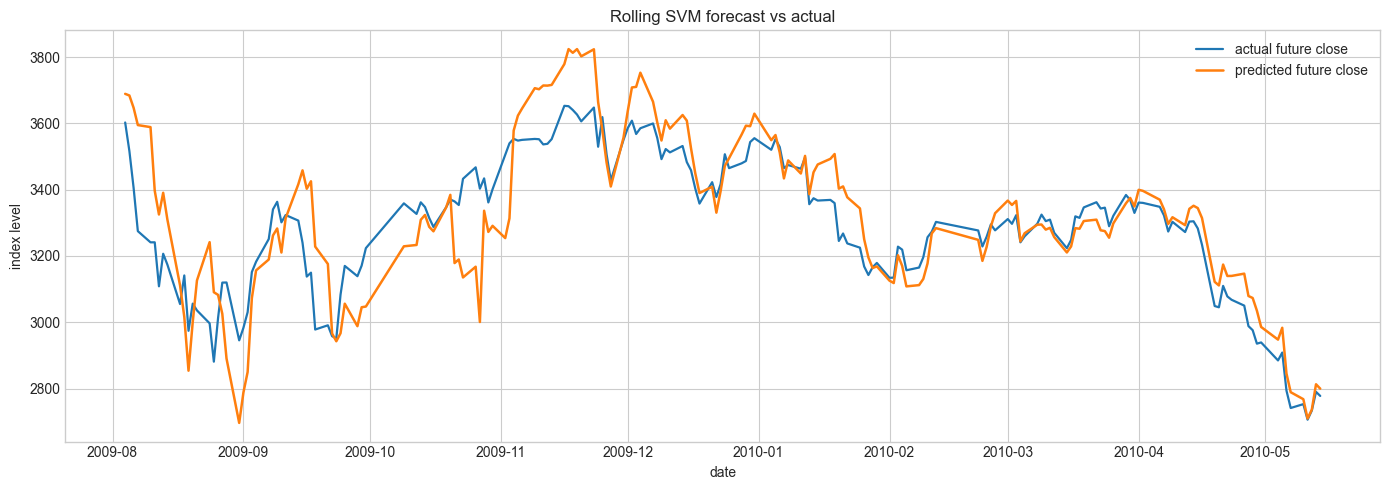

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(result["date"], result["actual_future_close"], label="actual future close", linewidth=1.6)
ax.plot(result["date"], result["pred_future_close"], label="predicted future close", linewidth=1.8)
ax.set_title("Rolling SVM forecast vs actual")
ax.set_xlabel("date")
ax.set_ylabel("index level")
ax.legend()
plt.tight_layout()
plt.show()


## 5. 金叉 / 死叉择时

这里按研报原文的写法来做：

- 真实走势上穿预测走势，记为金叉，按当日收盘价买入
- 真实走势下穿预测走势，记为死叉，按次日开盘价卖出
- 多空策略在死叉时转为空头，继续跟随下跌

这部分比“用预测方向直接下单”更接近原文，所以你会看到它的收益口径也更像研报。


long-only return   = 12.25%
long-short return  = 19.22%
benchmark return   = -24.26%


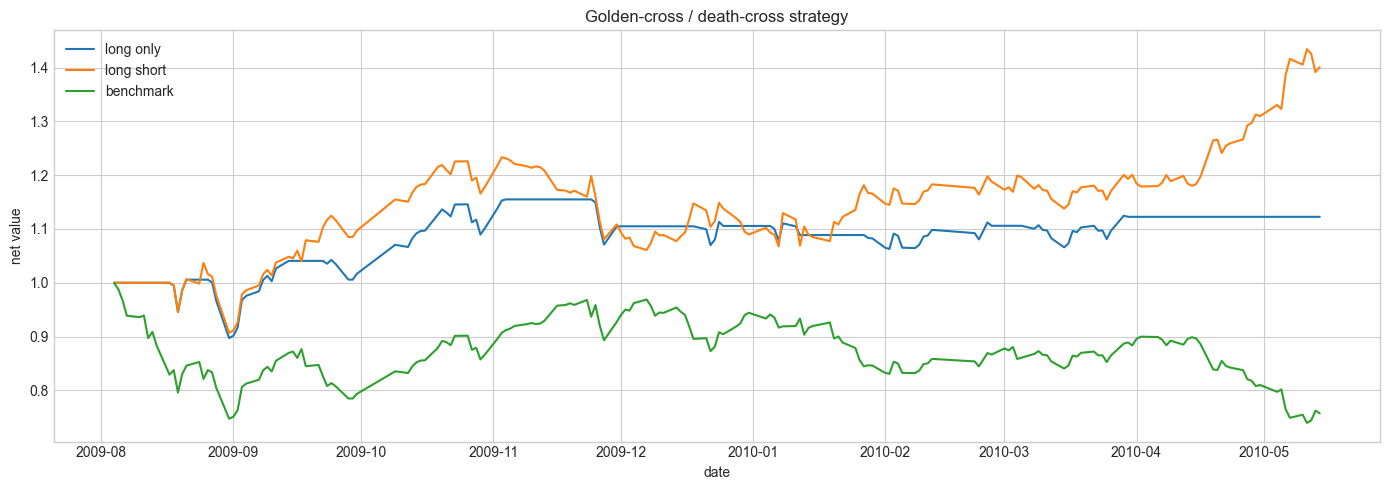

In [8]:
fee = 0.005
strategy = result.copy()
strategy["diff"] = strategy["actual_future_close"] - strategy["pred_future_close"]
strategy["prev_diff"] = strategy["diff"].shift(1)
strategy["golden_cross"] = (strategy["diff"] > 0) & (strategy["prev_diff"] <= 0)
strategy["death_cross"] = (strategy["diff"] < 0) & (strategy["prev_diff"] >= 0)

# 研报写的是“死叉次日开盘卖出”，所以这里补一个 next_open
next_open_map = df.set_index("date")["open"].shift(-1)
strategy["next_open"] = strategy["date"].map(next_open_map)

# 多头：金叉买入，死叉次日开盘卖出
long_capital = 1.0
long_pos = 0
long_entry = None
long_curve = []
for _, row in strategy.iterrows():
    if row["golden_cross"] and long_pos == 0:
        long_pos = 1
        long_entry = row["current_close"]
        long_capital *= (1 - fee)
    elif row["death_cross"] and long_pos == 1:
        long_exit = row["next_open"] if pd.notna(row["next_open"]) else row["current_close"]
        long_capital *= long_exit / long_entry
        long_capital *= (1 - fee)
        long_pos = 0
        long_entry = None

    if long_pos == 1 and long_entry is not None:
        long_curve.append(long_capital * row["current_close"] / long_entry)
    else:
        long_curve.append(long_capital)

if long_pos == 1 and long_entry is not None:
    long_capital *= strategy.iloc[-1]["current_close"] / long_entry

# 多空：金叉转多，死叉转空
ls_capital = 1.0
ls_pos = 0
ls_entry = None
ls_curve = []
for _, row in strategy.iterrows():
    if row["golden_cross"]:
        if ls_pos == -1:
            ls_capital *= ls_entry / row["current_close"]
            ls_capital *= (1 - fee)
        if ls_pos != 1:
            ls_pos = 1
            ls_entry = row["current_close"]
            ls_capital *= (1 - fee)
    elif row["death_cross"]:
        if ls_pos == 1:
            ls_exit = row["next_open"] if pd.notna(row["next_open"]) else row["current_close"]
            ls_capital *= ls_exit / ls_entry
            ls_capital *= (1 - fee)
        if ls_pos != -1:
            ls_pos = -1
            ls_entry = row["next_open"] if pd.notna(row["next_open"]) else row["current_close"]
            ls_capital *= (1 - fee)

    if ls_pos == 1 and ls_entry is not None:
        ls_curve.append(ls_capital * row["current_close"] / ls_entry)
    elif ls_pos == -1 and ls_entry is not None:
        ls_curve.append(ls_capital * ls_entry / row["current_close"])
    else:
        ls_curve.append(ls_capital)

strategy["long_nav"] = long_curve
strategy["ls_nav"] = ls_curve
strategy["idx_nav"] = strategy["current_close"] / strategy["current_close"].iloc[0]

print(f"long-only return   = {long_capital - 1:.2%}")
print(f"long-short return  = {ls_capital - 1:.2%}")
print(f"benchmark return   = {strategy['idx_nav'].iloc[-1] - 1:.2%}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(strategy["date"], strategy["long_nav"], label="long only")
ax.plot(strategy["date"], strategy["ls_nav"], label="long short")
ax.plot(strategy["date"], strategy["idx_nav"], label="benchmark")
ax.set_title("Golden-cross / death-cross strategy")
ax.set_xlabel("date")
ax.set_ylabel("net value")
ax.legend()
plt.tight_layout()
plt.show()
